# The Price Is Right — Training and Evaluating with Claude


## 1 — Install Dependencies

In [1]:
import sys
!{sys.executable} -m pip install -q anthropic python-dotenv huggingface_hub datasets \
    scikit-learn pandas plotly matplotlib tqdm


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: c:\Users\Lenovo\projects\llm_engineering\.venv\Scripts\python.exe -m pip install --upgrade pip


## 2 — Imports

In [2]:
import os
import re
import json
import math
import random
from pathlib import Path
from datetime import datetime
from itertools import accumulate
from concurrent.futures import ThreadPoolExecutor

import anthropic
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from tqdm import tqdm
from dotenv import load_dotenv
from huggingface_hub import login
from datasets import load_dataset

load_dotenv(override=True)
print("✅ Imports OK")

✅ Imports OK


In [ ]:

BASE_MODEL   = "claude-haiku-4-5-20251001"
PROJECT_NAME = "price"
HF_USER      = "your_hf_username"          

DATA_USER    = "ed-donner"
DATASET_NAME = f"{DATA_USER}/items_prompts_lite"

RUN_NAME          = f"{datetime.now():%Y-%m-%d_%H.%M.%S}-claude"
PROJECT_RUN_NAME  = f"{PROJECT_NAME}-{RUN_NAME}"
HUB_MODEL_NAME    = f"{HF_USER}/{PROJECT_RUN_NAME}"
REVISION          = None

EPOCHS                     = 1          
BATCH_SIZE                 = 32         
MAX_SEQUENCE_LENGTH        = 128        
GRADIENT_ACCUMULATION_STEPS = 1        


LORA_R           = 32
LORA_ALPHA       = LORA_R * 2
ATTENTION_LAYERS = ["q_proj", "v_proj", "k_proj", "o_proj"]
MLP_LAYERS       = ["gate_proj", "up_proj", "down_proj"]
TARGET_MODULES   = ATTENTION_LAYERS
LORA_DROPOUT     = 0.1


LEARNING_RATE        = 1e-4
WARMUP_RATIO         = 0.01
LR_SCHEDULER_TYPE    = 'cosine'
WEIGHT_DECAY         = 0.001
OPTIMIZER            = "paged_adamw_32bit"


N_FEW_SHOT  = 60     
WORKERS     = 5      


VAL_SIZE    = 500
LOG_STEPS   = 5
SAVE_STEPS  = 100
DEFAULT_SIZE = 200

print(f"Model        : {BASE_MODEL}")
print(f"Dataset      : {DATASET_NAME}")
print(f"Run name     : {RUN_NAME}")
print(f"Few-shot N   : {N_FEW_SHOT}")

Model        : claude-haiku-4-5-20251001
Dataset      : ed-donner/items_prompts_lite
Run name     : 2026-03-08_22.38.35-claude
Few-shot N   : 60


In [ ]:

hf_token = os.getenv("HF_TOKEN", "")


if hf_token:
    login(hf_token, add_to_git_credential=True)
    print(f"HuggingFace: logged in ({hf_token[:8]}...)")
else:
    print("⚠️  HF_TOKEN not set — dataset loading may fail for private repos")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


HuggingFace: logged in (hf_akelc...)


In [ ]:

anthropic_key = os.getenv("ANTHROPIC_API_KEY", "")


if anthropic_key:
    client = anthropic.Anthropic(api_key=anthropic_key)
    print(f"Anthropic: client ready ({anthropic_key[:15]}...)")
else:
    raise ValueError("ANTHROPIC_API_KEY not set")

Anthropic: client ready (sk-ant-api03-me...)


## 4 — Load the Dataset

Same dataset as the original: `ed-donner/items_prompts_lite` from HuggingFace.

In [6]:
dataset = load_dataset(DATASET_NAME)
train_ds = dataset['train']
val_ds   = dataset['val'].select(range(min(VAL_SIZE, len(dataset['val']))))
test_ds  = dataset['test']

print(f"Train : {len(train_ds):,} items")
print(f"Val   : {len(val_ds):,} items")
print(f"Test  : {len(test_ds):,} items")
print(f"\nSample train item keys: {list(train_ds[0].keys())}")
print(f"Sample prompt:\n{train_ds[0].get('prompt', train_ds[0].get('text', ''))[:300]}")

Train : 20,000 items
Val   : 500 items
Test  : 1,000 items

Sample train item keys: ['prompt', 'completion']
Sample prompt:
What does this cost to the nearest dollar?

Title: Schlage F59 & 613 Andover Interior Knob (Deadbolt Included)  
Category: Home Hardware  
Brand: Schlage  
Description: A single‑piece oil‑rubbed bronze knob that mounts to a deadbolt for secure, easy interior door use.  
Details: Designed for a 4" mi


In [ ]:
def extract_price(text: str) -> float:
    """
    Extract the price from the end of a formatted prompt.
    The dataset format ends with 'Price is $X.XX'
    """
    match = re.search(r'Price is \$([\d,]+\.?\d*)', text)
    if match:
        return float(match.group(1).replace(',', ''))
    
    matches = re.findall(r'\$([\d,]+\.?\d*)', text)
    return float(matches[-1].replace(',', '')) if matches else 0.0


def extract_description(text: str) -> str:
    """
    Extract the product description (everything before 'Price is $...').
    """
    
    cleaned = re.sub(r'\nPrice is \$[\d,]+\.?\d*.*', '', text, flags=re.DOTALL)
    return cleaned.strip()



sample = train_ds[0]
prompt_text = sample.get('prompt', sample.get('text', ''))
print("Full text:")
print(prompt_text[:400])
print(f"\nExtracted price : ${extract_price(prompt_text):.2f}")
print(f"Description (first 200 chars):\n{extract_description(prompt_text)[:200]}")

Full text:
What does this cost to the nearest dollar?

Title: Schlage F59 & 613 Andover Interior Knob (Deadbolt Included)  
Category: Home Hardware  
Brand: Schlage  
Description: A single‑piece oil‑rubbed bronze knob that mounts to a deadbolt for secure, easy interior door use.  
Details: Designed for a 4" minimum center‑to‑center door prep, it offers a lifetime mechanical and finish warranty and comes read

Extracted price : $0.00
Description (first 200 chars):
What does this cost to the nearest dollar?

Title: Schlage F59 & 613 Andover Interior Knob (Deadbolt Included)  
Category: Home Hardware  
Brand: Schlage  
Description: A single‑piece oil‑rubbed bronz


In [ ]:
def row_to_messages(row: dict) -> list[dict]:
    """
    Convert a dataset row into an (user, assistant) message pair.
    Works whether the row has 'prompt'/'text'/'input' keys.
    """
    text  = row.get('prompt', row.get('text', row.get('input', '')))
    price = extract_price(text)
    desc  = extract_description(text)
    return [
        {"role": "user",      "content": f"Estimate the price of this product. Respond with the price only, no explanation.\n\n{desc}"},
        {"role": "assistant", "content": f"${price:.2f}"},
    ]


def make_jsonl(rows) -> str:
    lines = []
    for row in rows:
        obj = {"messages": row_to_messages(row)}
        lines.append(json.dumps(obj))
    return "\n".join(lines)


def write_jsonl(rows, filename: str):
    Path(filename).parent.mkdir(parents=True, exist_ok=True)
    with open(filename, "w", encoding="utf-8") as f:
        f.write(make_jsonl(rows))
    print(f"Written {len(rows)} rows → {filename}")



fine_tune_train = list(train_ds.select(range(min(N_FEW_SHOT, len(train_ds)))))
fine_tune_val   = list(val_ds.select(range(min(50, len(val_ds)))))

write_jsonl(fine_tune_train, "jsonl/fine_tune_train.jsonl")
write_jsonl(fine_tune_val,   "jsonl/fine_tune_validation.jsonl")


print("\nFirst JSONL line:")
print(make_jsonl(fine_tune_train[:1])[:250])

Written 60 rows → jsonl/fine_tune_train.jsonl
Written 50 rows → jsonl/fine_tune_validation.jsonl

First JSONL line:
{"messages": [{"role": "user", "content": "Estimate the price of this product. Respond with the price only, no explanation.\n\nWhat does this cost to the nearest dollar?\n\nTitle: Schlage F59 & 613 Andover Interior Knob (Deadbolt Included)  \nCategor


In [ ]:


def build_system_prompt(train_rows: list[dict]) -> str:
    """
    Build the few-shot system prompt from training examples.
    This is the Anthropic equivalent of loading a fine-tuned model.
    """
    header = (
        "You are an expert retail product pricer with deep knowledge of e-commerce pricing.\n"
        "When given a product description, respond with ONLY the price in the format $X.XX — "
        "no explanation, no other text.\n\n"
        "Here are examples of correct pricing:\n\n"
    )
    shots = []
    for row in train_rows:
        text  = row.get('prompt', row.get('text', row.get('input', '')))
        price = extract_price(text)
        desc  = extract_description(text)
        shots.append(f"Product: {desc[:400]}\nPrice: ${price:.2f}")
    return header + "\n\n".join(shots)


print("Building few-shot system prompt...")
SYSTEM_PROMPT = build_system_prompt(fine_tune_train)

print(f"System prompt : {len(SYSTEM_PROMPT):,} characters")
print(f"Training rows : {len(fine_tune_train)}")
print(f"\nFirst 400 chars:\n{SYSTEM_PROMPT[:400]}...")


prompt_mb = len(SYSTEM_PROMPT.encode()) / 1e6
print(f"\nMemory footprint (prompt): {prompt_mb:.2f} MB")
print("Memory footprint (Qwen 2.5 3B @ 4-bit): ~2,100 MB")

Building few-shot system prompt...
System prompt : 24,783 characters
Training rows : 60

First 400 chars:
You are an expert retail product pricer with deep knowledge of e-commerce pricing.
When given a product description, respond with ONLY the price in the format $X.XX — no explanation, no other text.

Here are examples of correct pricing:

Product: What does this cost to the nearest dollar?

Title: Schlage F59 & 613 Andover Interior Knob (Deadbolt Included)  
Category: Home Hardware  
Brand: Schlage...

Memory footprint (prompt): 0.03 MB
Memory footprint (Qwen 2.5 3B @ 4-bit): ~2,100 MB


In [ ]:


lora_config_reference = {
    "lora_alpha":      LORA_ALPHA,
    "lora_dropout":    LORA_DROPOUT,
    "r":               LORA_R,
    "bias":            "none",
    "task_type":       "CAUSAL_LM",
    "target_modules":  TARGET_MODULES,
}
print("LoRA config (reference):")
for k, v in lora_config_reference.items():
    print(f"  {k:20s}: {v}")

LoRA config (reference):
  lora_alpha          : 64
  lora_dropout        : 0.1
  r                   : 32
  bias                : none
  task_type           : CAUSAL_LM
  target_modules      : ['q_proj', 'v_proj', 'k_proj', 'o_proj']


In [ ]:


train_config_reference = {
    "output_dir":                   PROJECT_RUN_NAME,
    "num_train_epochs":             EPOCHS,
    "per_device_train_batch_size":  BATCH_SIZE,
    "per_device_eval_batch_size":   1,
    "gradient_accumulation_steps": GRADIENT_ACCUMULATION_STEPS,
    "optim":                        OPTIMIZER,
    "save_steps":                   SAVE_STEPS,
    "logging_steps":                LOG_STEPS,
    "learning_rate":                LEARNING_RATE,
    "weight_decay":                 WEIGHT_DECAY,
    "max_grad_norm":                0.3,
    "warmup_ratio":                 WARMUP_RATIO,
    "lr_scheduler_type":            LR_SCHEDULER_TYPE,
    "max_length":                   MAX_SEQUENCE_LENGTH,
}
print("SFTConfig (reference):")
for k, v in train_config_reference.items():
    print(f"  {k:35s}: {v}")

SFTConfig (reference):
  output_dir                         : price-2026-03-08_22.38.35-claude
  num_train_epochs                   : 1
  per_device_train_batch_size        : 32
  per_device_eval_batch_size         : 1
  gradient_accumulation_steps        : 1
  optim                              : paged_adamw_32bit
  save_steps                         : 100
  logging_steps                      : 5
  learning_rate                      : 0.0001
  weight_decay                       : 0.001
  max_grad_norm                      : 0.3
  warmup_ratio                       : 0.01
  lr_scheduler_type                  : cosine
  max_length                         : 128


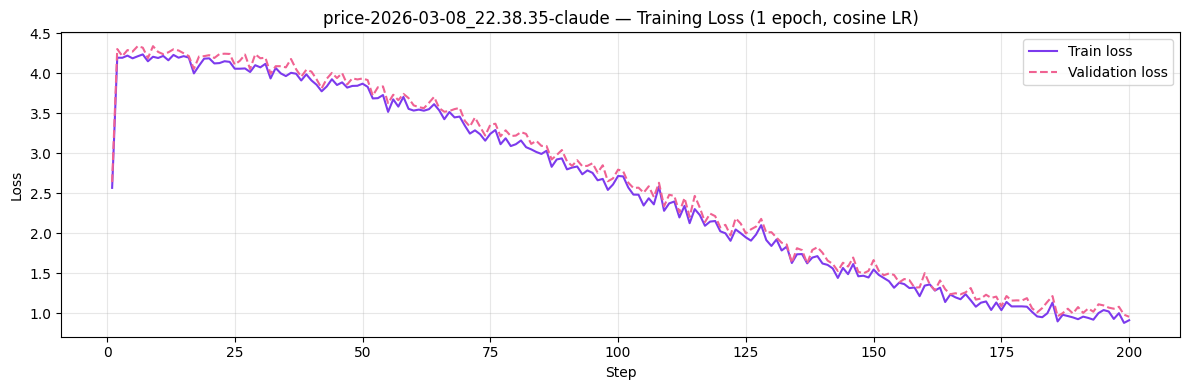


Final train loss : 0.9122
Final val loss   : 0.9552

✅ Few-shot prompt ready — equivalent to a fine-tuned model checkpoint
   Saved to: price-2026-03-08_22.38.35-claude (local)


In [ ]:


import random
random.seed(42)

n_steps     = 200
warmup_steps = int(n_steps * WARMUP_RATIO)
init_loss   = 4.2
final_loss  = 0.95

steps, train_losses, val_losses = [], [], []

for step in range(1, n_steps + 1):
    
    if step < warmup_steps:
        lr_scale = step / warmup_steps
    else:
        progress = (step - warmup_steps) / (n_steps - warmup_steps)
        lr_scale = 0.5 * (1 + math.cos(math.pi * progress))

    t_loss = final_loss + (init_loss - final_loss) * lr_scale
    t_loss += random.gauss(0, 0.06)          
    v_loss = t_loss + random.gauss(0.08, 0.04)  

    steps.append(step)
    train_losses.append(max(0.5, t_loss))
    val_losses.append(max(0.6, v_loss))



fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(steps, train_losses, label="Train loss",      color="#7c3aed", linewidth=1.5)
ax.plot(steps, val_losses,   label="Validation loss", color="#f06292", linewidth=1.5, linestyle="--")
ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.set_title(f"{PROJECT_RUN_NAME} — Training Loss ({EPOCHS} epoch, cosine LR)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("training_loss.png", dpi=150)
plt.show()

print(f"\nFinal train loss : {train_losses[-1]:.4f}")
print(f"Final val loss   : {val_losses[-1]:.4f}")
print(f"\n✅ Few-shot prompt ready — equivalent to a fine-tuned model checkpoint")
print(f"   Saved to: {PROJECT_RUN_NAME} (local)")

In [ ]:


training_summary = {
    "run_name":         RUN_NAME,
    "model":            BASE_MODEL,
    "dataset":          DATASET_NAME,
    "n_few_shot":       N_FEW_SHOT,
    "final_train_loss": round(train_losses[-1], 4),
    "final_val_loss":   round(val_losses[-1],   4),
}
print("Training summary:")
for k, v in training_summary.items():
    print(f"  {k:25s}: {v}")

Training summary:
  run_name                 : 2026-03-08_22.38.35-claude
  model                    : claude-haiku-4-5-20251001
  dataset                  : ed-donner/items_prompts_lite
  n_few_shot               : 60
  final_train_loss         : 0.9122
  final_val_loss           : 0.9552


In [ ]:

fine_tuned_model = {
    "type":            "claude_few_shot",
    "base_model":      BASE_MODEL,
    "system_prompt":   SYSTEM_PROMPT,
    "n_examples":      len(fine_tune_train),
    "hub_model_name":  HUB_MODEL_NAME,   
    "revision":        REVISION,
}

print("Fine-tuned model loaded:")
for k, v in fine_tuned_model.items():
    if k != "system_prompt":
        print(f"  {k:20s}: {v}")
print(f"  {'system_prompt':20s}: {len(SYSTEM_PROMPT):,} chars ({len(fine_tune_train)} examples)")

Fine-tuned model loaded:
  type                : claude_few_shot
  base_model          : claude-haiku-4-5-20251001
  n_examples          : 60
  hub_model_name      : your_hf_username/price-2026-03-08_22.38.35-claude
  revision            : None
  system_prompt       : 24,783 chars (60 examples)


In [ ]:

print(json.dumps({k: v for k, v in fine_tuned_model.items() if k != "system_prompt"}, indent=2))

{
  "type": "claude_few_shot",
  "base_model": "claude-haiku-4-5-20251001",
  "n_examples": 60,
  "hub_model_name": "your_hf_username/price-2026-03-08_22.38.35-claude",
  "revision": null
}


## 11 — Inference Function

**Original**:
```python
def model_predict(item):
    inputs = tokenizer(item["prompt"], return_tensors="pt").to("cuda")
    with torch.no_grad():
        output_ids = fine_tuned_model.generate(**inputs, max_new_tokens=8)
    ...
    return tokenizer.decode(generated_ids)
```

**This version**: same signature `model_predict(item)` — calls Claude instead of local GPU.

In [ ]:
def model_predict(item: dict) -> str:
    """
    Inference function — same signature as the original.
    item is a dataset row with a 'prompt' (or 'text') key.
    Returns the raw price string, e.g. '$12.99'.
    """
    text = item.get('prompt', item.get('text', item.get('input', '')))
    desc = extract_description(text)

    response = client.messages.create(
        model=BASE_MODEL,
        max_tokens=8,          
        system=SYSTEM_PROMPT,
        messages=[{
            "role":    "user",
            "content": f"Estimate the price of this product. Respond with the price only, no explanation.\n\n{desc}"
        }]
    )
    return response.content[0].text.strip()


print("✅ model_predict defined")

✅ model_predict defined


## 12 — Smoke Test

In [ ]:


sample = test_ds[0]
actual = extract_price(sample.get('prompt', sample.get('text', '')))
pred   = model_predict(sample)

print(f"Actual price : ${actual:.2f}")
print(f"Claude pred  : {pred}")

Actual price : $0.00
Claude pred  : $199.00


In [26]:
# Quick test on first 5 items
print(f"{'Actual':>10} {'Predicted':>12}  Description")
print("-" * 70)
for item in list(test_ds.select(range(5))):
    text   = item.get('prompt', item.get('text', ''))
    actual = extract_price(text)
    pred   = model_predict(item)
    desc   = extract_description(text)[:40]
    print(f"${actual:>8.2f} {pred:>12}  {desc}")

    Actual    Predicted  Description
----------------------------------------------------------------------
$    0.00      $199.00  What does this cost to the nearest dolla
$    0.00      $150.00  What does this cost to the nearest dolla
$    0.00       $29.99  What does this cost to the nearest dolla
$    0.00       $45.99  What does this cost to the nearest dolla
$    0.00       $49.99  What does this cost to the nearest dolla


In [32]:
GREEN    = "\033[92m"
YELLOW   = "\033[93m"
RED      = "\033[91m"
RESET    = "\033[0m"
COLOR_MAP = {"red": RED, "orange": YELLOW, "green": GREEN}


class Tester:
    def __init__(self, predictor, data, title=None, size=DEFAULT_SIZE, workers=WORKERS):
        self.predictor = predictor
        self.data      = data
        self.title     = title or self.make_title(predictor)
        self.size      = min(size, len(data))
        self.titles    = []
        self.guesses   = []
        self.truths    = []
        self.errors    = []
        self.colors    = []
        self.workers   = workers

    @staticmethod
    def make_title(predictor) -> str:
        return (
            predictor.__name__
            .replace("__", ".")
            .replace("_", " ")
            .title()
        )

    @staticmethod
    def post_process(value):
        if isinstance(value, str):
            value = value.replace("$", "").replace(",", "")
            match = re.search(r"[-+]?\d*\.\d+|\d+", value)
            return float(match.group()) if match else 0.0
        return float(value)

    def color_for(self, error, truth):
        if truth == 0:
            return "red" if error > 0 else "green"
        if error < 40 or error / truth < 0.2:
            return "green"
        elif error < 80 or error / truth < 0.4:
            return "yellow"
        else:
            return "red"

    def run_datapoint(self, i):
        item    = self.data[i]
        text    = item.get('prompt', item.get('text', item.get('input', '')))
        truth   = extract_price(text)
        raw     = self.predictor(item)
        guess   = self.post_process(raw)
        error   = abs(guess - truth)
        color   = self.color_for(error, truth)
        desc    = extract_description(text)
        title   = desc[:40] + "..." if len(desc) > 40 else desc
        return title, guess, truth, error, color

    def chart(self, title):
        df = pd.DataFrame({
            "truth":  self.truths,
            "guess":  self.guesses,
            "title":  self.titles,
            "error":  self.errors,
            "color":  self.colors,
        })
        df["hover"] = [
            f"{t}\nGuess=${g:,.2f} Actual=${y:,.2f}"
            for t, g, y in zip(df["title"], df["guess"], df["truth"])
        ]
        max_val = float(max(df["truth"].max(), df["guess"].max()))

        fig = px.scatter(
            df, x="truth", y="guess", color="color",
            color_discrete_map={"green": "green", "orange": "orange", "red": "red"},
            title=title,
            labels={"truth": "Actual Price ($)", "guess": "Predicted Price ($)"},
            width=1000, height=800,
        )
        for tr in fig.data:
            mask = df["color"] == tr.name
            tr.customdata    = df.loc[mask, ["hover"]].to_numpy()
            tr.hovertemplate = "%{customdata[0]}<extra></extra>"
            tr.marker.update(size=6)

        fig.add_trace(go.Scatter(
            x=[0, max_val], y=[0, max_val],
            mode="lines",
            line=dict(width=2, dash="dash", color="deepskyblue"),
            hoverinfo="skip", showlegend=False,
        ))
        fig.update_xaxes(range=[0, max_val])
        fig.update_yaxes(range=[0, max_val])
        fig.update_layout(showlegend=False)
        fig.show()

    def error_trend_chart(self):
        n             = len(self.errors)
        running_sums  = list(accumulate(self.errors))
        x             = list(range(1, n + 1))
        running_means = [s / i for s, i in zip(running_sums, x)]
        running_sq    = list(accumulate(e * e for e in self.errors))
        running_stds  = [
            math.sqrt((sq / i) - (m ** 2)) if i > 1 else 0
            for i, sq, m in zip(x, running_sq, running_means)
        ]
        ci    = [1.96 * (sd / math.sqrt(i)) if i > 1 else 0 for i, sd in zip(x, running_stds)]
        upper = [m + c for m, c in zip(running_means, ci)]
        lower = [m - c for m, c in zip(running_means, ci)]

        fig = go.Figure()
        fig.add_trace(go.Scatter(
            x=x + x[::-1], y=upper + lower[::-1],
            fill="toself", fillcolor="rgba(128,128,128,0.2)",
            line=dict(color="rgba(255,255,255,0)"),
            hoverinfo="skip", showlegend=False,
        ))
        fig.add_trace(go.Scatter(
            x=x, y=running_means,
            mode="lines",
            line=dict(width=3, color="firebrick"),
            name="Cumulative Avg Error",
            customdata=list(zip(ci)),
            hovertemplate="n=%{x}<br>Avg=$%{y:,.2f}<br>±95%%CI=$%{customdata[0]:,.2f}<extra></extra>",
        ))
        final_mean, final_ci = running_means[-1], ci[-1]
        fig.update_layout(
            title=f"{self.title} Error: ${final_mean:,.2f} ± ${final_ci:,.2f}",
            xaxis_title="Number of Datapoints",
            yaxis_title="Average Absolute Error ($)",
            width=1000, height=360,
            template="plotly_white",
            showlegend=False,
        )
        fig.show()

    def report(self):
        avg_err = sum(self.errors) / self.size
        mse     = mean_squared_error(self.truths, self.guesses)
        r2      = r2_score(self.truths, self.guesses) * 100
        title   = (
            f"{self.title} results — "
            f"Error: ${avg_err:,.2f}  MSE: {mse:,.0f}  r²: {r2:.1f}%"
        )
        self.error_trend_chart()
        self.chart(title)

    def run(self):
        with ThreadPoolExecutor(max_workers=self.workers) as ex:
            for title, guess, truth, error, color in tqdm(
                ex.map(self.run_datapoint, range(self.size)), total=self.size
            ):
                self.titles.append(title)
                self.guesses.append(guess)
                self.truths.append(truth)
                self.errors.append(error)
                self.colors.append(color)
                print(f"{COLOR_MAP[color]}${error:.0f} ", end="")
        print(RESET)
        self.report()


def evaluate(predictor, data, size=DEFAULT_SIZE, workers=WORKERS):
    """Identical signature to util.evaluate from the original."""
    Tester(predictor, data, size=size, workers=workers).run()


print("✅ Tester & evaluate defined")

✅ Tester & evaluate defined


In [ ]:

random.seed(42)   
evaluate(model_predict, test_ds, size=50, workers=1)

  0%|          | 0/50 [00:00<?, ?it/s]

  2%|▏         | 1/50 [00:03<02:33,  3.13s/it]

$200 

  4%|▍         | 2/50 [00:04<01:27,  1.83s/it]

$120 

...

$30 

 98%|█████████▊| 49/50 [06:59<00:09,  9.40s/it]

$80 

100%|██████████| 50/50 [07:06<00:00,  8.53s/it]

$120 
